# Deep-feature MLP baseline (CNN-equivalent on pooled embeddings)

Sanity baseline: discard the graph entirely, take the mean over the 4096 nodes of the multilevel deep features, feed the resulting `(D,)` vector to a small MLP. If this matches/beats SGCN-deep or GAT, the graph structure isn't contributing — useful finding either way.

Tail-merge is auto-enabled for L2/L3; flat CE is the default training objective.

In [1]:
from pathlib import Path
import importlib
import warnings; warnings.filterwarnings('ignore')

import fgvd_utils
fgvd_utils = importlib.reload(fgvd_utils)
ExperimentConfig = fgvd_utils.ExperimentConfig
run_experiment = fgvd_utils.run_experiment

CKPT_ROOT = Path('checkpoints')
PLOT_ROOT = Path('plots')

## L1 — vehicle type


=== CNN | L1 | deep | hierarchical=False | tail_min=None ===
Samples: train=15702 val=3850 test=4890 | classes=7
Epoch 001 | train_acc=0.8098 val_acc=0.8423 | train_loss=0.9147 val_loss=0.8225
Epoch 005 | train_acc=0.8700 val_acc=0.8566 | train_loss=0.7338 val_loss=0.7720
Epoch 010 | train_acc=0.8815 val_acc=0.8655 | train_loss=0.6970 val_loss=0.7536
Epoch 015 | train_acc=0.8868 val_acc=0.8644 | train_loss=0.6782 val_loss=0.7423
Epoch 020 | train_acc=0.8947 val_acc=0.8675 | train_loss=0.6621 val_loss=0.7479
Epoch 025 | train_acc=0.8996 val_acc=0.8649 | train_loss=0.6473 val_loss=0.7420
Epoch 030 | train_acc=0.9028 val_acc=0.8699 | train_loss=0.6393 val_loss=0.7415
Epoch 035 | train_acc=0.9073 val_acc=0.8665 | train_loss=0.6287 val_loss=0.7501
Epoch 040 | train_acc=0.9105 val_acc=0.8657 | train_loss=0.6182 val_loss=0.7402
Epoch 045 | train_acc=0.9151 val_acc=0.8714 | train_loss=0.6073 val_loss=0.7353
Epoch 050 | train_acc=0.9189 val_acc=0.8691 | train_loss=0.5973 val_loss=0.7489

Test 

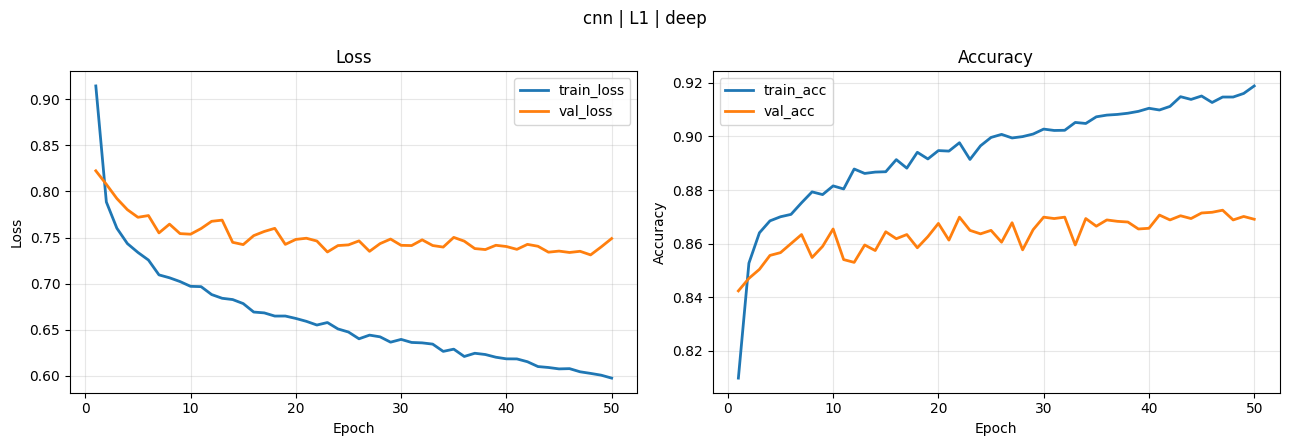

{'loss': 0.42995525320614775,
 'acc': 0.8685071574642127,
 'macro_f1': 0.7989129876021099,
 'weighted_f1': 0.8680334220906875,
 'top1_acc': 0.8685071574642127,
 'top3_acc': 0.9783231083844581,
 'top5_acc': 0.9948875255623721,
 'val_acc_best': 0.8724675324675325}

In [2]:
cfg_l1 = ExperimentConfig(
    method='cnn', level='L1', feature_source='deep',
    epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4,
    dropout=0.4,
    use_logit_adjustment=False,
)
out_l1 = run_experiment(cfg_l1, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l1['metrics']

## L2 — manufacturer


=== CNN | L2 | deep | hierarchical=False | tail_min=20 ===
Samples: train=15702 val=3850 test=4890 | classes=46
Tail-merge: kept 41/59 classes | coverage train=0.991 val=0.990 test=0.992
AMP mixed precision: enabled
Checkpoint training config differs — starting fresh.
  Existing checkpoint has no run signature.
Epoch 001 | train_acc=0.2792 val_acc=0.4083 | train_loss=3.6670 val_loss=3.2473
Epoch 005 | train_acc=0.3638 val_acc=0.4325 | train_loss=3.0075 val_loss=3.0268
Epoch 010 | train_acc=0.3861 val_acc=0.4210 | train_loss=2.8848 val_loss=2.9735
Epoch 015 | train_acc=0.3943 val_acc=0.4397 | train_loss=2.8125 val_loss=2.9416
Epoch 020 | train_acc=0.4063 val_acc=0.4268 | train_loss=2.7535 val_loss=2.8931
Epoch 025 | train_acc=0.4201 val_acc=0.4312 | train_loss=2.7098 val_loss=2.9002
Epoch 030 | train_acc=0.4177 val_acc=0.4455 | train_loss=2.6739 val_loss=2.8831
Epoch 035 | train_acc=0.4311 val_acc=0.4327 | train_loss=2.6266 val_loss=2.8775
Epoch 040 | train_acc=0.4327 val_acc=0.4475 | 

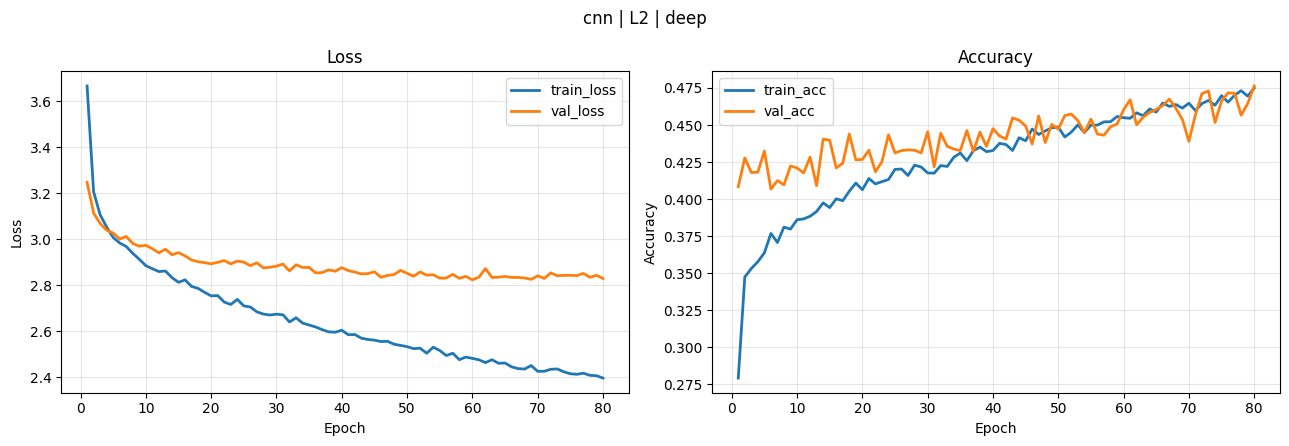

{'loss': 1.9684813328803439,
 'acc': 0.45807770961145194,
 'macro_f1': 0.329415826366105,
 'weighted_f1': 0.47177730172426774,
 'top1_acc': 0.45807770961145194,
 'top3_acc': 0.723721881390593,
 'top5_acc': 0.8157464212678937,
 'val_acc_best': 0.4763636363636364}

In [2]:
cfg_l2 = ExperimentConfig(
    method='cnn', level='L2', feature_source='deep',
    epochs=80, batch_size=128, lr=1e-3, weight_decay=1e-4,
    dropout=0.5,
    hierarchical=False,
)
out_l2 = run_experiment(cfg_l2, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l2['metrics']

## L3 — model


=== CNN | L3 | deep | hierarchical=False | tail_min=20 ===
Samples: train=15702 val=3850 test=4890 | classes=135
Tail-merge: kept 93/209 classes | coverage train=0.955 val=0.951 test=0.953
AMP mixed precision: enabled
Epoch 001 | train_acc=0.1033 val_acc=0.2610 | train_loss=6.1524 val_loss=5.5443
Epoch 005 | train_acc=0.2249 val_acc=0.3016 | train_loss=5.2018 val_loss=5.1393
Epoch 010 | train_acc=0.2435 val_acc=0.3021 | train_loss=4.9655 val_loss=5.0168
Epoch 015 | train_acc=0.2640 val_acc=0.3036 | train_loss=4.8314 val_loss=4.9644
Epoch 020 | train_acc=0.2747 val_acc=0.3091 | train_loss=4.7300 val_loss=4.9316
Epoch 025 | train_acc=0.2826 val_acc=0.3106 | train_loss=4.6233 val_loss=4.8958
Epoch 030 | train_acc=0.2924 val_acc=0.3109 | train_loss=4.5717 val_loss=4.8948
Epoch 035 | train_acc=0.2934 val_acc=0.3275 | train_loss=4.5198 val_loss=4.8507
Epoch 040 | train_acc=0.3103 val_acc=0.3405 | train_loss=4.4547 val_loss=4.8302
Epoch 045 | train_acc=0.3070 val_acc=0.3345 | train_loss=4.41

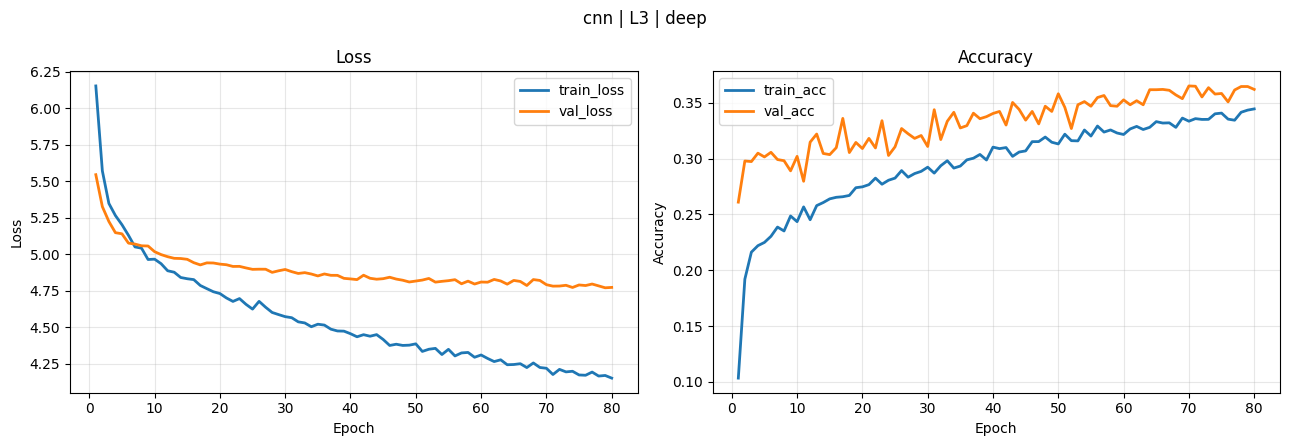

{'loss': 3.0364533599900323,
 'acc': 0.3478527607361963,
 'macro_f1': 0.2176558023365413,
 'weighted_f1': 0.3742363756461025,
 'top1_acc': 0.3478527607361963,
 'top3_acc': 0.5149284253578732,
 'top5_acc': 0.5899795501022495,
 'val_acc_best': 0.3651948051948052}

In [3]:
cfg_l3 = ExperimentConfig(
    method='cnn', level='L3', feature_source='deep',
    epochs=80, batch_size=128, lr=1e-3, weight_decay=1e-4,
    dropout=0.5,
    hierarchical=False,
)
out_l3 = run_experiment(cfg_l3, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l3['metrics']